<a href="https://colab.research.google.com/github/Claud1601/CN7030-Assignment/blob/main/PortfolioExerciseweek4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark

from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Python Spark SQL basic example") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#raw_data = spark.read.format("csv").option("header","true").option("inferSchema", "true").load(r".\\diabetes.csv")
dataset = spark.read.csv('/content/titanic_synthetic_data.csv',inferSchema=True, header =True)

In [4]:
# what are the columns in this dataset
dataset.columns

['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Sex',
 'Survived',
 'Embarked_Q',
 'Embarked_S']

In [5]:
dataset.describe().select("Summary","Pclass","Age","SibSp","Sex").show()

+-------+------------------+------------------+------------------+------------------+
|Summary|            Pclass|               Age|             SibSp|               Sex|
+-------+------------------+------------------+------------------+------------------+
|  count|           1000000|           1000000|           1000000|           1000000|
|   mean|          1.999411|         39.517847|          4.500906|           0.50082|
| stddev|0.8168263709530482|23.092708389398037|2.8714427426552285|0.4999995775993916|
|    min|                 1|                 0|                 0|                 0|
|    max|                 3|                79|                 9|                 1|
+-------+------------------+------------------+------------------+------------------+



In [6]:
dataset.describe().select("Summary","Parch","Fare").show()

+-------+------------------+------------------+
|Summary|             Parch|              Fare|
+-------+------------------+------------------+
|  count|           1000000|           1000000|
|   mean|          4.497493| 254.9829083944402|
| stddev|2.8728101169393594|141.53963219142216|
|    min|                 0|10.000191449724019|
|    max|                 9| 499.9999338139367|
+-------+------------------+------------------+



In [7]:
dataset.describe().select("Summary","Sex","Survived","Embarked_Q").show()

+-------+------------------+------------------+-------------------+
|Summary|               Sex|          Survived|         Embarked_Q|
+-------+------------------+------------------+-------------------+
|  count|           1000000|           1000000|            1000000|
|   mean|           0.50082|           0.49987|           0.332717|
| stddev|0.4999995775993916|0.5000002331001768|0.47118639616145436|
|    min|                 0|                 0|                  0|
|    max|                 1|                 1|                  1|
+-------+------------------+------------------+-------------------+



In [8]:
from pyspark.sql.functions import col,isnan, when, count
dataset.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in dataset.columns]
   ).show()

+------+---+-----+-----+----+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+----+---+--------+----------+----------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|
+------+---+-----+-----+----+---+--------+----------+----------+



In [9]:
# replace min value of zeros with Nan as data cleaning processs
import numpy as np
from pyspark.sql.functions import when
dataset=dataset.withColumn("Pclass",when(dataset.Pclass==0,np.nan).otherwise (dataset.Pclass))
dataset=dataset.withColumn("Age",when(dataset.Age==0,np.nan).otherwise(dataset.Age))
dataset=dataset.withColumn("SibSp",when(dataset.SibSp==0,np.nan).otherwise(dataset.SibSp))
dataset=dataset.withColumn("Parch",when(dataset.Parch==0,np.nan).otherwise(dataset.Parch))
dataset=dataset.withColumn("Fare",when(dataset.Fare==0,np.nan).otherwise(dataset.Fare))
dataset=dataset.withColumn("Sex",when(dataset.Sex==0,np.nan).otherwise(dataset.Sex))
dataset=dataset.withColumn("Survived",when(dataset.Survived==0,np.nan).otherwise(dataset.Survived))
dataset=dataset.withColumn("Embarked_Q",when(dataset.Embarked_Q==0,np.nan).otherwise(dataset.Embarked_Q))
dataset=dataset.withColumn("Embarked_S",when(dataset.Embarked_S==0,np.nan).otherwise(dataset.Embarked_S))
dataset.select("Pclass","Age","SibSp","Parch","Fare","Sex","Survived","Embarked_Q","Embarked_S").show(9)

+------+----+-----+-----+------------------+---+--------+----------+----------+
|Pclass| Age|SibSp|Parch|              Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+----+-----+-----+------------------+---+--------+----------+----------+
|   3.0|42.0|  6.0|  7.0|397.00178367782024|NaN|     NaN|       NaN|       1.0|
|   1.0|52.0|  6.0|  7.0|302.12770032784186|NaN|     NaN|       1.0|       NaN|
|   3.0|25.0|  3.0|  8.0| 427.1058765283985|1.0|     1.0|       1.0|       NaN|
|   3.0|32.0|  9.0|  7.0| 326.8049924602327|1.0|     NaN|       NaN|       NaN|
|   1.0|40.0|  NaN|  5.0|17.718838497771657|NaN|     NaN|       NaN|       NaN|
|   1.0|20.0|  7.0|  2.0|402.54904361394784|NaN|     NaN|       NaN|       NaN|
|   3.0|76.0|  4.0|  9.0| 52.61038014285054|NaN|     NaN|       1.0|       NaN|
|   2.0|22.0|  4.0|  7.0|196.48213366632623|1.0|     NaN|       NaN|       NaN|
|   3.0|78.0|  4.0|  8.0| 388.6259182464271|1.0|     NaN|       NaN|       NaN|
+------+----+-----+-----+---------------

In [10]:
# check again NAN values
from pyspark.sql.functions import col,isnan, when, count
dataset.select([count(when(isnan(c) , c)).alias(c) for c in dataset.columns]
   ).show()

+------+-----+-----+------+----+------+--------+----------+----------+
|Pclass|  Age|SibSp| Parch|Fare|   Sex|Survived|Embarked_Q|Embarked_S|
+------+-----+-----+------+----+------+--------+----------+----------+
|     0|12475|99708|100052|   0|499180|  500130|    667283|    666339|
+------+-----+-----+------+----+------+--------+----------+----------+



In [22]:
#us combine all the features in one single feature vector.
cols=dataset.columns.copy()
# Remove the target variable 'Survived' and the 'features' column if it already exists
if "Survived" in cols:
    cols.remove("Survived")
if "features" in cols:
    cols.remove("features")

# If 'features' column already exists in the DataFrame, drop it before re-creating
if "features" in dataset.columns:
    dataset = dataset.drop("features")

# Let us import the vector assembler
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols=cols,outputCol="features")
# Now let us use the transform method to transform our dataset
dataset=assembler.transform(dataset)
dataset.select("features").show(truncate=False)

+---------------------------------------------------------------+
|features                                                       |
+---------------------------------------------------------------+
|[3.0,42.0,6.0,7.0,397.00178367782024,1.0,1.0,1.0]              |
|[1.0,52.0,6.0,7.0,302.12770032784186,1.0,1.0,1.0]              |
|[3.0,25.0,3.0,8.0,427.1058765283985,1.0,1.0,1.0]               |
|[3.0,32.0,9.0,7.0,326.8049924602327,1.0,1.0,1.0]               |
|[1.0,40.0,4.99938464409325,5.0,17.718838497771657,1.0,1.0,1.0] |
|[1.0,20.0,7.0,2.0,402.54904361394784,1.0,1.0,1.0]              |
|[3.0,76.0,4.0,9.0,52.61038014285054,1.0,1.0,1.0]               |
|[2.0,22.0,4.0,7.0,196.48213366632623,1.0,1.0,1.0]              |
|[3.0,78.0,4.0,8.0,388.6259182464271,1.0,1.0,1.0]               |
|[3.0,15.0,1.0,8.0,299.45900279822325,1.0,1.0,1.0]              |
|[3.0,68.0,8.0,7.0,479.98134512112455,1.0,1.0,1.0]              |
|[3.0,3.0,7.0,1.0,93.03405698775256,1.0,1.0,1.0]                |
|[1.0,63.0

In [23]:
#Standard Sclarizer
from pyspark.ml.feature import StandardScaler
standardscaler=StandardScaler().setInputCol("features").setOutputCol("Scaled_features")
dataset=standardscaler.fit(dataset).transform(dataset)
dataset.select("features","Scaled_features").show(5)

+--------------------+--------------------+
|            features|     Scaled_features|
+--------------------+--------------------+
|[3.0,42.0,6.0,7.0...|[3.67275115824148...|
|[1.0,52.0,6.0,7.0...|[1.22425038608049...|
|[3.0,25.0,3.0,8.0...|[3.67275115824148...|
|[3.0,32.0,9.0,7.0...|[3.67275115824148...|
|[1.0,40.0,4.99938...|[1.22425038608049...|
+--------------------+--------------------+
only showing top 5 rows


In [24]:
#Train, test split
train, test = dataset.randomSplit([0.8, 0.2], seed=12345)

In [26]:
#imbalance in the dataset, observe the use of Where
dataset_size=float(train.select("Survived").count())
numPositives=train.select("Survived").where('Survived == 1').count()
per_ones=(float(numPositives)/float(dataset_size))*100
numNegatives=float(dataset_size-numPositives)
print('The number of ones are {}'.format(numPositives))
print('Percentage of ones are {}'.format(per_ones))

The number of ones are 800244
Percentage of ones are 100.0


In [27]:
BalancingRatio= numNegatives/dataset_size
print('BalancingRatio = {}'.format(BalancingRatio))

BalancingRatio = 0.0


In [29]:
# balance
train=train.withColumn("classWeights", when(train.Survived == 1,BalancingRatio).otherwise(1-BalancingRatio))
train.select("classWeights").show(5)

+------------+
|classWeights|
+------------+
|         0.0|
|         0.0|
|         0.0|
|         0.0|
|         0.0|
+------------+
only showing top 5 rows


In [31]:
print("Unique values in 'Survived' column of train dataset:")
train.select("Survived").distinct().show()

Unique values in 'Survived' column of train dataset:
+--------+
|Survived|
+--------+
|     1.0|
+--------+



In [45]:
import pandas as pd

df = pd.read_csv('/content/titanic_synthetic_data.csv', engine='python', sep=',', on_bad_lines='skip')

print('DataFrame Head:')
display(df.head())

print('\nDataFrame Info:')
display(df.info())

print('\nDataFrame Description:')
display(df.describe(include='all'))

DataFrame Head:


,Pclass,Age,SibSp,Parch,Fare,Sex,Survived,Embarked_Q,Embarked_S
0,3,42,6,7,397.001784,0,0,0,1
1,1,52,6,7,302.127700,0,0,1,0
2,3,25,3,8,427.105877,1,1,1,0
3,3,32,9,7,326.804992,1,0,0,0
4,1,40,0,5,17.718838,0,0,0,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   Pclass      1000000 non-null  int64  
 1   Age         1000000 non-null  int64  
 2   SibSp       1000000 non-null  int64  
 3   Parch       1000000 non-null  int64  
 4   Fare        1000000 non-null  float64
 5   Sex         1000000 non-null  int64  
 6   Survived    1000000 non-null  int64  
 7   Embarked_Q  1000000 non-null  int64  
 8   Embarked_S  1000000 non-null  int64  
dtypes: float64(1), int64(8)
memory usage: 68.7 MB


None


DataFrame Description:


,Pclass,Age,SibSp,Parch,Fare,Sex,Survived,Embarked_Q,Embarked_S
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.00000,1000000.000000,1000000.000000
mean,1.999411,39.517847,4.500906,4.497493,254.982908,0.50082,0.49987,0.332717,0.333661
std,0.816826,23.092708,2.871443,2.872810,141.539632,0.50000,0.50000,0.471186,0.471520
min,1.000000,0.000000,0.000000,0.000000,10.000191,0.00000,0.00000,0.000000,0.000000
25%,1.000000,19.000000,2.000000,2.000000,132.470297,0.00000,0.00000,0.000000,0.000000
50%,2.000000,40.000000,5.000000,4.000000,254.706445,1.00000,0.00000,0.000000,0.000000
75%,3.000000,60.000000,7.000000,7.000000,377.506871,1.00000,1.00000,1.000000,1.000000
max,3.000000,79.000000,9.000000,9.000000,499.999934,1.00000,1.00000,1.000000,1.000000


In [36]:
import pandas as pd

df = pd.read_csv('/content/titanic_synthetic_data.csv', engine='python', sep=',', on_bad_lines='skip')

# Drop rows where 'Survived' is NaN first, as it's the target variable for stratification
df.dropna(subset=['Survived'], inplace=True)

# Convert 'Fare' to numeric, coercing errors (non-numeric values will become NaN)
df['Fare'] = pd.to_numeric(df['Fare'], errors='coerce')

# Fill missing 'Age' with the median (avoiding inplace=True in chained assignment)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing numerical columns with their median (avoiding inplace=True in chained assignment)
# Iterate only over columns that are actually present in the DataFrame after initial loading.
columns_to_fill_median = ['SibSp', 'Fare', 'Sex', 'Embarked_Q', 'Embarked_S']
for col in columns_to_fill_median:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Remove non-existent columns from original request to prevent KeyErrors
# (e.g., 'Cabin', 'PassengerId', 'Name', 'Ticket', 'Embarked' are not in this dataset)
# No explicit drops needed here as these columns were not present initially and thus not loaded.

print('\nDataFrame Info after handling missing values and ensuring numeric types:')
display(df.info())


DataFrame Info after handling missing values and ensuring numeric types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   Pclass      1000000 non-null  int64  
 1   Age         1000000 non-null  int64  
 2   SibSp       1000000 non-null  int64  
 3   Parch       1000000 non-null  int64  
 4   Fare        1000000 non-null  float64
 5   Sex         1000000 non-null  int64  
 6   Survived    1000000 non-null  int64  
 7   Embarked_Q  1000000 non-null  int64  
 8   Embarked_S  1000000 non-null  int64  
dtypes: float64(1), int64(8)
memory usage: 68.7 MB


None

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define target and features
X = df.drop('Survived', axis=1)
y = df['Survived']

# Identify categorical and numerical features dynamically after cleaning
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print(f"Categorical features: {list(categorical_features)}")
print(f"Numerical features: {list(numerical_features)}")

Categorical features: []
Numerical features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Embarked_Q', 'Embarked_S']


Distribution of the target variable (Survived):


,count
Survived,
0,500130
1,499870


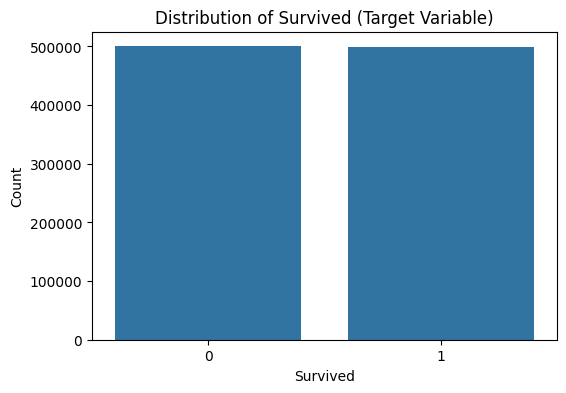

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

print('Distribution of the target variable (Survived):')
display(y.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribution of Survived (Target Variable)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()


Distribution of the target variable (Survived) after SMOTE:


,count
Survived,
1,400104
0,400104


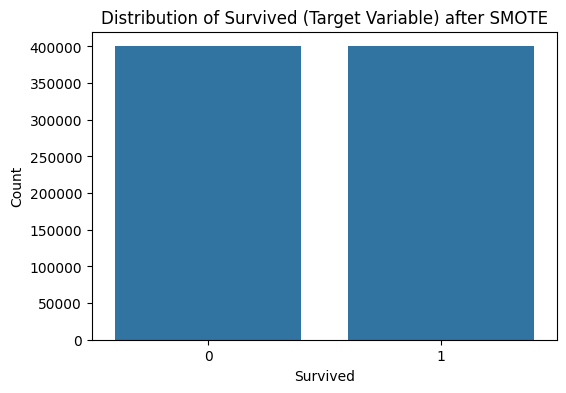

In [42]:
!pip install imblearn

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Ensure target variable 'y' is integer type for SMOTE and consistent stratification
y = y.astype(int)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply preprocessing to training data (scaling numerical, one-hot encoding categorical)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Apply SMOTE to the training data only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_processed, y_train)

print('\nDistribution of the target variable (Survived) after SMOTE:')
display(pd.Series(y_train_res).value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_res)
plt.title('Distribution of Survived (Target Variable) after SMOTE')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # liblinear is good for small datasets and handles L1/L2 regularization
model.fit(X_train_res, y_train_res)

# Make predictions on the processed test set
y_pred = model.predict(X_test_processed)

# Evaluate the model
print('\nModel Evaluation:')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nConfusion Matrix:')
display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=['Actual Not Survived', 'Actual Survived'], columns=['Predicted Not Survived', 'Predicted Survived']))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Model Evaluation:
Accuracy: 0.4978

Confusion Matrix:


,Predicted Not Survived,Predicted Survived
Actual Not Survived,49874,50152
Actual Survived,50293,49681



Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50    100026
           1       0.50      0.50      0.50     99974

    accuracy                           0.50    200000
   macro avg       0.50      0.50      0.50    200000
weighted avg       0.50      0.50      0.50    200000

